# Bank Marketing Campaign Response Prediction

## 1. Problem Definition

The objective of this project is to develop a machine learning model that predicts whether a customer will subscribe to a bank term deposit after a direct marketing campaign.

The prediction problem is a binary classification task where the target variable indicates whether a customer subscribed to the term deposit.

### Target Variable

The target variable is:

**y**

- yes: Customer subscribed to the term deposit
- no: Customer did not subscribe

### Unit of Analysis

Each record represents one customer contacted during a bank marketing campaign.

### Business Value

The predictive model helps the bank:
- Identify customers with a higher likelihood of subscription.
- Improve marketing campaign efficiency.
- Reduce unnecessary customer contacts.
- Increase conversion rates and revenue.

### Import Required Libraries

In [18]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

### Load Dataset

In [50]:
df = pd.read_csv(
    "bank-full.csv",
    sep=";"
)
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


#### Dataset Shape

In [51]:
df.shape

(45211, 17)

#### Dataset Information

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


#### Statistical Summary

In [53]:
df.describe(include='all')

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,45211.000000,45211,45211,45211,45211,45211.000000,45211,45211,45211,45211.000000,45211,45211.000000,45211.000000,45211.000000,45211.000000,45211,45211
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,9732,27214,23202,44396,NaN,25130,37967,29285,NaN,13766,NaN,NaN,NaN,NaN,36959,39922
mean,40.936210,NaN,NaN,NaN,NaN,1362.272058,NaN,NaN,NaN,15.806419,NaN,258.163080,2.763841,40.197828,0.580323,NaN,NaN
std,10.618762,NaN,NaN,NaN,NaN,3044.765829,NaN,NaN,NaN,8.322476,NaN,257.527812,3.098021,100.128746,2.303441,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-8019.000000,NaN,NaN,NaN,1.000000,NaN,0.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,33.000000,NaN,NaN,NaN,NaN,72.000000,NaN,NaN,NaN,8.000000,NaN,103.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,448.000000,NaN,NaN,NaN,16.000000,NaN,180.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,48.000000,NaN,NaN,NaN,NaN,1428.000000,NaN,NaN,NaN,21.000000,NaN,319.000000,3.000000,-1.000000,0.000000,NaN,NaN


### Check Missing Values

In [54]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [55]:
unknown_values = (df == "unknown").sum()

unknown_values[unknown_values > 0]

job            288
education     1857
contact      13020
poutcome     36959
dtype: int64

### Numerical Variables

In [56]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns

print(numerical_cols)

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')


### Categorical Variables

In [57]:
categorical_cols = df.select_dtypes(include=['object']).columns

print(categorical_cols)

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')


### Duplicate Records

In [60]:
df.duplicated().sum()

0

### Check target variable

In [64]:
df['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [69]:
df['y'].value_counts(normalize=True)*100

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

## Visualizations

### Job vs Subscription Outcome

This visualization compares term deposit subscription rates across different job categories.

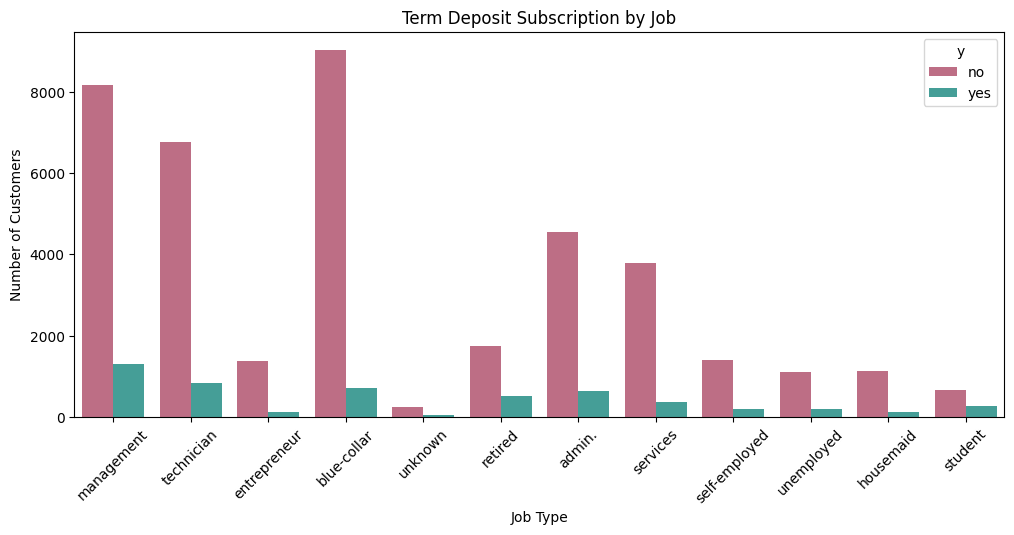

In [82]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x='job',
    hue='y',
    palette=[ '#CA6180','#36ADA3']
)

plt.title("Term Deposit Subscription by Job")
plt.xticks(rotation=45)
plt.xlabel("Job Type")
plt.ylabel("Number of Customers")
plt.show()

#### Interpretation

Customers in the **management**, **technician**, and **admin.** job categories recorded the highest numbers of subscriptions, suggesting these groups are more responsive to marketing campaigns. **Retired** and **student** customers also show relatively higher subscription rates compared to their group sizes, while **blue-collar** and **services** customers exhibit lower subscription success despite having many contacts. Overall, the majority of customers in every job category did not subscribe, indicating an imbalanced response distribution.

### Marital Status vs Subscription

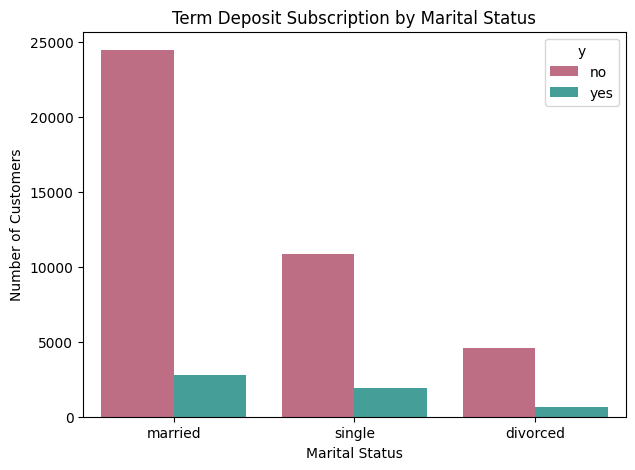

In [85]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='marital',
    hue='y',
    palette=[ '#CA6180','#36ADA3']
)

plt.title("Term Deposit Subscription by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Number of Customers")
plt.show()

#### Interpretation

- **Married customers** represent the largest group and contribute the highest number of term deposit subscriptions due to their large representation in the dataset.
- **Single customers** show a relatively stronger response pattern compared to their group size, indicating higher engagement with marketing campaigns.
- **Divorced customers** recorded fewer subscriptions, partly due to their smaller population size.
- Across all marital groups, **non-subscription remains dominant**, confirming the imbalance in the target variable.

### Education vs Subscription

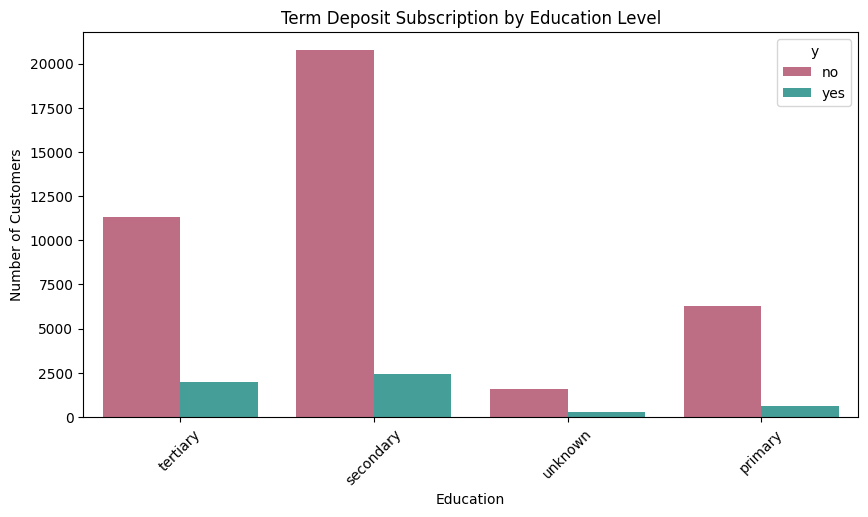

In [73]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    x='education',
    hue='y',
    palette=[ '#CA6180','#36ADA3']
)
plt.title("Term Deposit Subscription by Education Level")
plt.xticks(rotation=45)
plt.xlabel("Education")
plt.ylabel("Number of Customers")
plt.show()

#### Interpretation

- **Secondary education customers** form the largest customer group and contribute the highest number of subscriptions due to their large representation in the dataset.
- **Tertiary education customers show stronger campaign responsiveness relative to their group size**, indicating that higher education levels may be associated with greater interest in term deposits.
- **Primary education customers have fewer subscriptions compared to other education groups**, suggesting lower response rates to the marketing campaign.
- Customers with **unknown education levels show limited subscription activity**, although they represent a smaller portion of the dataset.
- Across all education categories, **non-subscription remains the dominant outcome**, confirming the imbalance in campaign responses.

### Contact Type vs Subscription

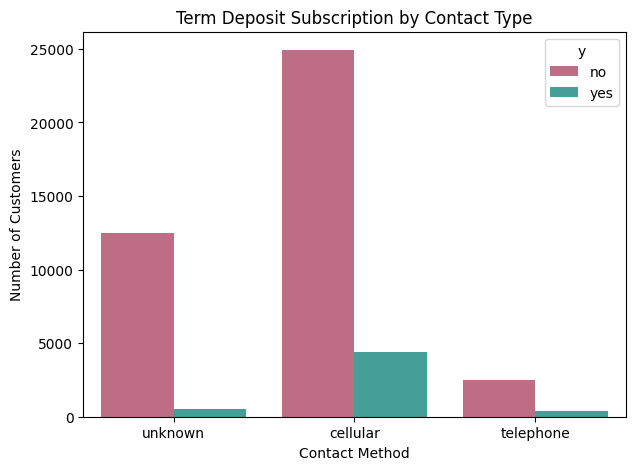

In [89]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='contact',
    hue='y',
    palette=[ '#CA6180','#36ADA3']
)

plt.title("Term Deposit Subscription by Contact Type")
plt.xlabel("Contact Method")
plt.ylabel("Number of Customers")
plt.show()

#### Interpretation

- **Cellular contacts recorded the highest number of subscriptions**, suggesting that mobile communication was more effective for reaching customers.
- **Telephone contacts had fewer subscriptions**, while unknown contact types showed the lowest response rate.
- Customers contacted through known communication channels were more likely to subscribe compared to customers with missing contact information.
- Non-subscription outcomes remain dominant across all contact types.

### Previous Campaign Outcome vs Subscription

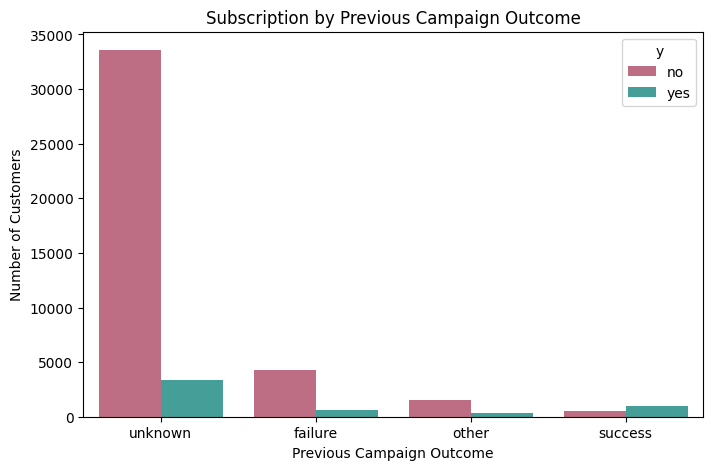

In [75]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='poutcome',
    hue='y',
    palette=[ '#CA6180','#36ADA3']
)

plt.title("Subscription by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Number of Customers")
plt.show()

#### Interpretation

- Customers with a **successful previous campaign outcome had the highest subscription response**, indicating previous success is a strong predictor of future acceptance.
- Customers with **failure or other previous outcomes showed lower subscription levels**.
- Customers with **unknown previous outcomes represent the largest group but have a low subscription rate**, suggesting limited prior engagement information.
- Previous campaign performance appears to influence customer response behaviour.

### Age Group vs Subscription

In [76]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[18,30,40,50,60,100],
    labels=['18-30','31-40','41-50','51-60','60+']
)

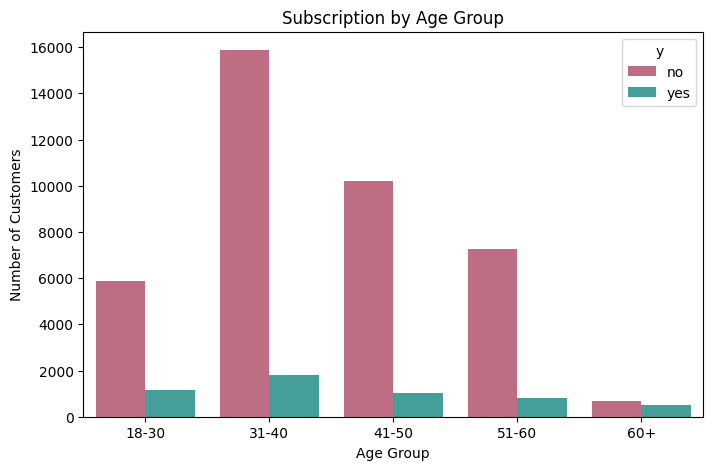

In [77]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='age_group',
    hue='y',
    palette=[ '#CA6180','#36ADA3']
)

plt.title("Subscription by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.show()

#### Interpretation

- The **31–40 age group** is the largest customer segment and contributes the highest number of subscriptions.
- The **60+ age group shows the strongest response rate relative to its size**, suggesting older customers may be more interested in term deposits.
- Younger customers (**18–30**) also show relatively good engagement compared to middle-aged groups.
- Across all age groups, non-subscription remains dominant, showing the overall imbalance in campaign responses.

### Balance vs Subscription

In [78]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,age_group
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,51-60
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,41-50
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,31-40
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,41-50
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,31-40


In [79]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y', 'age_group'],
      dtype='object')

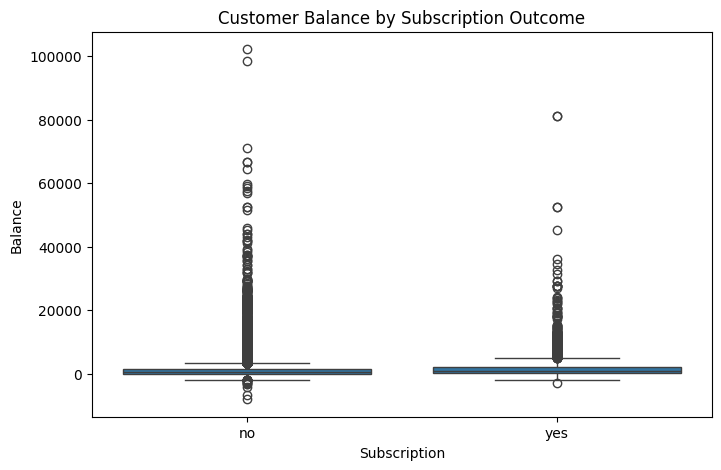

In [80]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='y',
    y='balance'
)

plt.title("Customer Balance by Subscription Outcome")
plt.xlabel("Subscription")
plt.ylabel("Balance")
plt.show()

#### Interpretation

- Customers who subscribed (**yes**) had a higher average balance (1,804) compared to non-subscribers (1,304), suggesting financial capacity may influence subscription decisions.
- The median balance was also higher among subscribers, indicating that customers with stronger account balances showed greater interest in term deposits.
- Both groups contain customers with negative balances and extreme values, showing high variation in customer financial profiles.
- Balance appears to be a useful predictor for distinguishing customers likely to subscribe.

### Campaign Contact Frequency vs Subscription

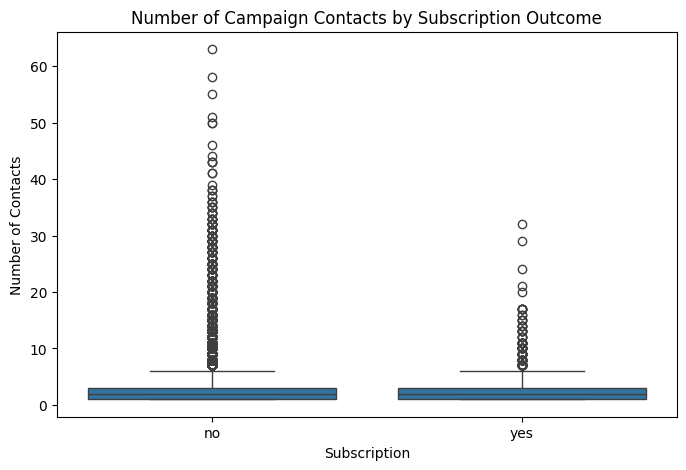

In [81]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='y',
    y='campaign'
)

plt.title("Number of Campaign Contacts by Subscription Outcome")
plt.xlabel("Subscription")
plt.ylabel("Number of Contacts")
plt.show()

#### Interpretation

- Customers who subscribed had a lower average number of campaign contacts (2.14) compared to non-subscribers (2.85).
- Excessive contact attempts may reduce customer response, suggesting possible campaign fatigue.
- Most customers received between 1–3 contacts, but extreme values show some customers were contacted many times.
- Campaign frequency is therefore an important factor when predicting subscription outcomes.

## Data Preparation for Modelling

### Handling Unknown Categories

In [94]:
# Check unknown categories
unknown_values = (df == "unknown").sum()

unknown_values[unknown_values > 0]

job            288
education     1857
contact      13020
poutcome     36959
dtype: int64

The dataset contains `"unknown"` values in some categorical variables. Instead of removing these records, the unknown values are retained as a separate category because they may contain useful information about customer behaviour. One-hot encoding with `handle_unknown='ignore'` is applied to safely process unseen categories during prediction.

### Create Campaign Intensity Features

In [97]:
# Current campaign contact intensity
df['contact_intensity'] = df['campaign'] / (df['previous'] + 1)

# Total customer contacts across campaigns
df['total_contacts'] = df['campaign'] + df['previous']

# Indicator for customers previously contacted
df['was_previously_contacted'] = (df['previous'] > 0).astype(int)

df[['campaign',
    'previous',
    'contact_intensity',
    'total_contacts',
    'was_previously_contacted']].head()

,campaign,previous,contact_intensity,total_contacts,was_previously_contacted
0,1,0,1.0,1,0
1,1,0,1.0,1,0
2,1,0,1.0,1,0
3,1,0,1.0,1,0
4,1,0,1.0,1,0


- contact_intensity - measures how aggressively the customer was contacted in the current campaign compared to past interactions.
- total_contacts - captures the customer's overall marketing exposure.
- was_previously_contacted - distinguishes new customers from customers with previous campaign history.

### Separate Predictors and Target Variable

In [98]:
X = df.drop('y', axis=1)

y = df['y']

print(X.shape)
print(y.shape)

(45211, 21)
(45211,)


### Identify Numerical and Categorical Variables

In [99]:
numeric_features = X.select_dtypes(
    include=['int64','float64']
).columns

categorical_features = X.select_dtypes(
    include=['object']
).columns


print("Numerical Features:")
print(list(numeric_features))

print("\nCategorical Features:")
print(list(categorical_features))

Numerical Features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'contact_intensity', 'total_contacts', 'was_previously_contacted', 'previous_success']

Categorical Features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


### Handling Unknown Categories, Encoding and Scaling

In [100]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify feature types
numeric_features = X.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_features = X.select_dtypes(
    include=['object']
).columns


# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

### Prepare Target Variable

In [101]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

pd.Series(y).value_counts()

0    39922
1     5289
Name: count, dtype: int64

### Data Splitting

The dataset is divided into training and testing sets using stratified sampling to maintain the same subscription distribution in both datasets.

In [102]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Handling Class Imbalance - class weighting as the main approach

The target variable is highly imbalanced, with fewer customers subscribing to term deposits. Class weighting is applied to give more importance to the minority class during model training.

### Apply Preprocessing + Train Models

#### Logistic Regression

In [103]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000
    ))
])


lr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous',
       'contact_intensity', 'total_contacts', 'was_previously_contacted',
       'previous_success'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

#### Random Forest

In [104]:
from sklearn.ensemble import RandomForestClassifier


rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        class_weight='balanced',
        random_state=42
    ))
])


rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous',
       'contact_intensity', 'total_contacts', 'was_previously_contacted',
       'previous_success'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

#### XGBoost

In [107]:
# Calculate class imbalance ratio for XGBoost

class_ratio = (y_train == 0).sum() / (y_train == 1).sum()

print("Scale position weight:", class_ratio)

Scale position weight: 7.548333727251241


In [108]:
from xgboost import XGBClassifier


xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        scale_pos_weight=class_ratio
    ))
])


xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous',
       'contact_intensity', 'total_contacts', 'was_previously_contacted',
       'previous_success'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['job', 'marital', 'education', 'default',...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

### Model Selection Summary

- Logistic Regression was used as a baseline model due to its simplicity and interpretability.
- Random Forest was selected because it captures nonlinear relationships and interactions among customer features.
- XGBoost uses `scale_pos_weight` to address class imbalance. The value is calculated from the ratio of majority class samples to minority class samples, giving more importance to the smaller subscription class during model training.
- Class weighting was applied to address the imbalance between subscribed and non-subscribed customers.

## Generate Predictions

In [109]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}


results = []

for name, model in models.items():
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })


results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.846179,0.418899,0.812854,0.552877,0.907983
1,Random Forest,0.902687,0.678715,0.319471,0.434447,0.927118
2,XGBoost,0.874710,0.478705,0.796786,0.598084,0.923854


### Model Evaluation Interpretation

- Random Forest achieved the highest accuracy (90.27%) and ROC-AUC (0.927), indicating strong overall classification performance.

- XGBoost achieved the highest F1-score (0.598) with high recall (0.797), showing a better balance between identifying subscribers and reducing incorrect predictions.

- Logistic Regression achieved the highest recall (0.813), meaning it identified most subscribers, but its lower precision indicates more false positives.

- Due to the imbalanced target variable, F1-score, recall, and ROC-AUC provide better evaluation than accuracy alone.

- **XGBoost is selected as the preferred model** because it provides the best balance between finding potential subscribers and maintaining prediction reliability.

### ROC Curve Comparison

The ROC curve compares the trade-off between correctly identifying subscribers and false positive predictions. A higher area under the curve (ROC-AUC) indicates better model discrimination.

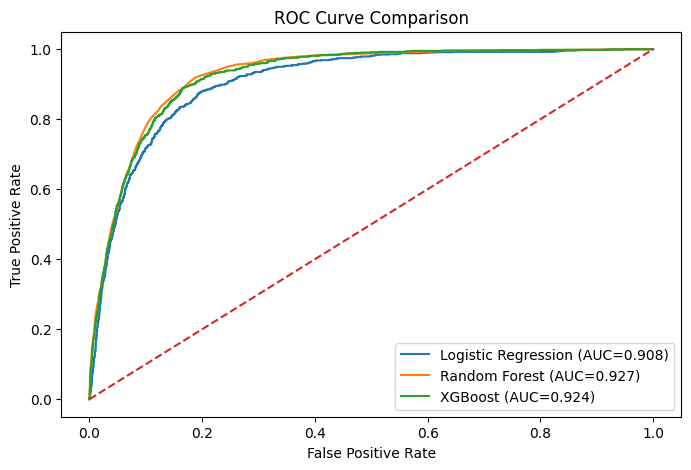

In [112]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,5))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={roc_auc:.3f})"
    )


plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

### Precision-Recall Curve Comparison

The precision-recall curve is used because the dataset contains fewer subscribing customers. It evaluates how effectively models identify the minority subscription class.

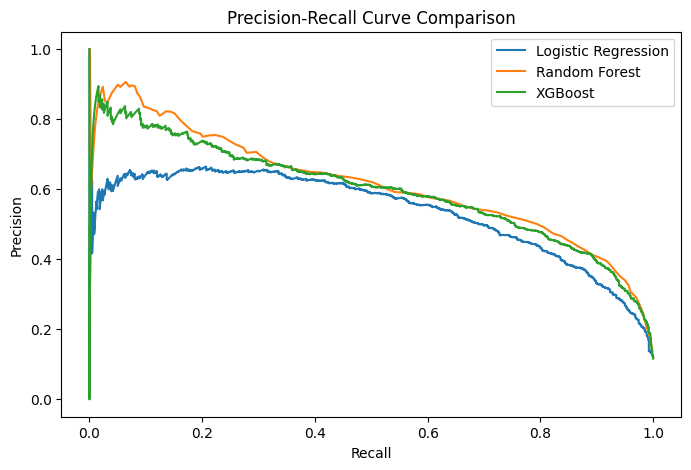

In [113]:
from sklearn.metrics import precision_recall_curve


plt.figure(figsize=(8,5))


for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    plt.plot(
        recall,
        precision,
        label=name
    )


plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve Comparison")

plt.legend()

plt.show()